# Лабораторная работа 9

## Цель
Построить **прогноз на 8 месяцев** методом **экспоненциального сглаживания** временного ряда

### Вариант 1
Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения процента занятых номеров за один день. Усреднение по отелям и по дням месяца
Данные расположены в столбце x1 файла Chicago_hotels.csv

**Период наблюдений:** январь 1994 — апрель 2003. **Прогноз:** май — декабрь 2003

### Идея метода

Для месячного ряда с периодом сезонности 12 используется модель **тренд + сезонность** с экспоненциальным обновлением уровня, наклона тренда и сезонных коэффициентов. 

#### Структура модели

Наблюдение $y_t$ представляется как сумма сглаженного уровня, линейного тренда и сезонной поправки

$$
y_t = \ell_t + b_t + s_t + \varepsilon_t
$$

Оценка компонент на каждом шаге обновляется экспоненциально:

$$
\begin{aligned}
\ell_t &= \alpha (y_t - s_{t-p}) + (1-\alpha)(\ell_{t-1} + b_{t-1}) \\[4pt]
b_t &= \beta (\ell_t - \ell_{t-1}) + (1-\beta) b_{t-1} \\[4pt]
s_t &= \gamma (y_t - \ell_t) + (1-\gamma) s_{t-p}
\end{aligned}
$$


$\alpha, \beta, \gamma$ — параметры сглаживания. Автоматически подбираются минимизацией суммы квадратов одношаговых ошибок прогноза на обучающей выборке.

#### Прогнозирование

Прогноз на $n$ шагов вперёд вычисляется как:

$$
\hat{y}_{t+n} = \ell_t + n \cdot b_t + s_{t+n-p}
$$

## Загрузка данных и подготовка ряда

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["font.size"] = 11

DATA_PATH = "data.csv"

raw = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8")
raw["x1"] = pd.to_numeric(raw["x1"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
raw = raw.dropna(subset=["x1"]).copy()

raw["date"] = pd.to_datetime(
    raw["date1"].astype(str) + " " + raw["date2"].astype(str),
    format="%B %Y",
    errors="coerce",
)
raw = raw.dropna(subset=["date"]).sort_values("date")
series = raw.set_index("date")["x1"].asfreq("MS")

print(f"Число наблюдений: {len(series)}")
print(f"Период: с {series.index.min().date()} по {series.index.max().date()}")
series.head()

Число наблюдений: 112
Период: с 1994-01-01 по 2003-04-01


date
1994-01-01    44.3
1994-02-01    54.7
1994-03-01    61.9
1994-04-01    69.1
1994-05-01    70.8
Freq: MS, Name: x1, dtype: float64

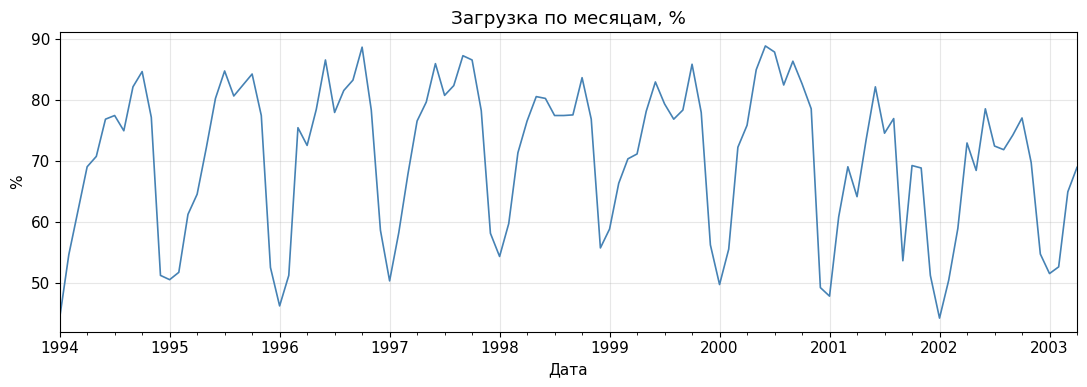

In [4]:
fig, ax = plt.subplots()
series.plot(ax=ax, color="steelblue", linewidth=1.2)
ax.set_title("Загрузка по месяцам, %")
ax.set_xlabel("Дата")
ax.set_ylabel("%")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Построение прогноза

Подбираем аддитивный тренд и сезонность с периодом 12 

Параметры сглаживания оптимизируются (`optimized=True`)

Значение `initialization_method` берется по умолчанию

In [9]:
HORIZON = 8

model = ExponentialSmoothing(
    series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
)
fit = model.fit(optimized=True)

fitted = fit.fittedvalues
forecast = fit.forecast(HORIZON)
forecast_index = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(), periods=HORIZON, freq="MS")
forecast.index = forecast_index

print(fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                       x1   No. Observations:                  112
Model:             ExponentialSmoothing   SSE                           1869.945
Optimized:                         True   AIC                            347.299
Trend:                         Additive   BIC                            390.795
Seasonal:                      Additive   AICC                           354.653
Seasonal Periods:                    12   Date:                 Thu, 09 Apr 2026
Box-Cox:                          False   Time:                         11:01:45
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.3767409                alpha                 True
smoothing_trend          

### График

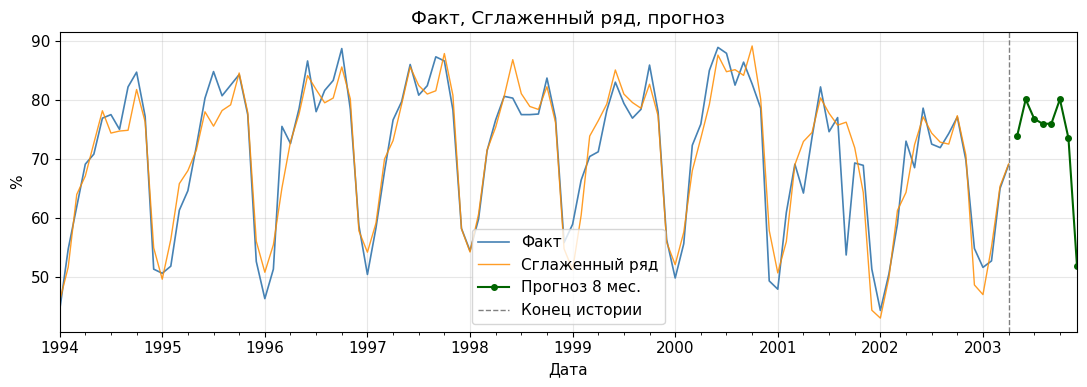

In [13]:
fig, ax = plt.subplots()
series.plot(ax=ax, label="Факт", color="steelblue", linewidth=1.2)
fitted.plot(ax=ax, label="Сглаженный ряд", color="darkorange", linewidth=1, alpha=0.85)
forecast.plot(ax=ax, label="Прогноз 8 мес.", color="darkgreen", linewidth=1.5, marker="o", markersize=4)
ax.axvline(series.index[-1], color="gray", linestyle="--", linewidth=1, label="Конец истории")
ax.set_title("Факт, Сглаженный ряд, прогноз")
ax.set_xlabel("Дата")
ax.set_ylabel("%")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Вывод

Ниже — численные значения прогноза по месяцам (май–декабрь 2003).

In [7]:
forecast_table = pd.DataFrame({
    "месяц": forecast.index.strftime("%Y-%m"),
    "прогноз_загрузка_%": np.round(forecast.values, 2),
})
forecast_table

,месяц,прогноз_загрузка_%
0,2003-05,73.90
1,2003-06,80.09
2,2003-07,76.78
3,2003-08,75.94
4,2003-09,75.96
5,2003-10,80.11
6,2003-11,73.51
7,2003-12,51.81


- Для месячного ряда с явной годовой сезонностью применено **трёхкомпонентное экспоненциальное сглаживание** (уровень, тренд, сезонность)
- Прогноз на 8 месяцев получен экстраполяцией оценённого тренда и повторением сезонного паттерна
- Качество описания истории можно судить по близости оранжевой линии к фактическому ряду и по информационным критериям AIC/BIC